In [ ]:
%load_ext autoreload
%autoreload 2
import numpy as np
import analysis_code.get_data as get_data
import matplotlib.pyplot as plt
import analysis_code.population_activity as pop
import analysis_code.helper_functions as hf
import analysis_code.analysis as analysis
import analysis_code.plots as plots
import analysis_code.statistics_test as st
import analysis_code.nullspace_drift as nullspace_drift
import analysis_code.decoding2 as decoding2

from IPython.display import display, HTML
def print_large(text):
    display(HTML(f"<span style='font-size: 20px;'>{text}</span>"))
from pathlib import Path
#OUT = Path("figures"); OUT.mkdir(exist_ok=True)
import matplotlib as mpl
mpl.rcParams.update({
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
    "pdf.fonttype": 42,   
    "ps.fonttype": 42,    
})

DATA_ROOT = 'DATAPATH'  
datapaths = [
    f'{DATA_ROOT}/170.h5',
    f'{DATA_ROOT}/51004.h5',
    f'{DATA_ROOT}/51007.h5',
    f'{DATA_ROOT}/63.h5',
    f'{DATA_ROOT}/64.h5',
    f'{DATA_ROOT}/65.h5',
]

c:\Users\oles\miniforge3\envs\nature_nn_demo\lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.3 when it was built against 1.14.2, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


In [2]:
maps = [str(i) for i in np.arange(1, 13)] +  ['14', '15', '17', '19']
maps_reverse =  ['17', '15', '14'] + [str(i) for i in np.arange(12, -1, -1)]
days1 = [str(i) for i in np.arange(0, 13)] +  ['14', '15', '17', '19']
days2 = ['19','17', '15', '14'] + [str(i) for i in np.arange(12, -1, -1)]

configs = [
    ('Context1', maps, '0', days1, False, False),  
    ('Context1', None, '0', days1, False, True)
     
]

def run_analysis(datapath, context, sessions, ref_session, days, cross, is_drift):
    if not is_drift:
        res_align = analysis.loop_sessions_2datas(analysis.AK_align_2_sets2, datapath, ref_session, sessions, context, cross, 'dpca', 6)
    else:
        simu_drift = analysis.simulate_drift(
            datapath, session=ref_session, Context=context, days=len(days),
            drift_type='circular', standardize='stand', odd_even=True, 
            global_seed=0, remove_day_inactive=True
        )
        res_align = analysis.loop_sessions_3(
            analysis.AK_align_2_sets_sim, 
            simu_drift['drift_data'][0], 
            simu_drift['drift_data'][1:], 
            simu_drift['pos'],
            'dpca', 6
        )

    translation_scale = [r[8] for r in res_align]
    ref = [r[0][r[2]] for r in res_align]
    align_population = [r[1][r[2]] for r in res_align]
    align_population.insert(0, ref[0])

    pop_correlation = [pop.ManifoldAnalysis.population_correlation(res_align[day][1], res_align[0][0]) for day in range(len(res_align))]
    error = [[r[3][6], r[3][5]] for r in res_align]
    rotated_data2 = [r[4] for r in res_align]
    pos_data2 = [r[5] for r in res_align]
    data1 = res_align[0][6]          # (T1,N)
    pos_data1 = res_align[0][7]      # (T1,)

    drift_quadrants = nullspace_drift.split_drift_quadrants(res_align, data1, pos_data1)

    nullpot = nullspace_drift.compute_null_potent_fractions(res_align, data1, pos_data1)

    null_within = nullspace_drift.null_rigid_vs_residual_within_null(res_align, data1, pos_data1)


    return {
        'ref': ref,
        'align_population': align_population,
        'days': days,
        'pop_correlation': pop_correlation,
        'translation_scale': translation_scale,
        'errors': error,
        'drift_quadrants': drift_quadrants,   
        'nullpot': nullpot,
        'null_within': null_within
    }

results = {}
for i, (context, sessions, ref_session, days, cross, is_drift) in enumerate(configs):
    config_name = f"config_{i+1}"
    results[config_name] = {}
    for datapath in datapaths:
        file_name = datapath.split('/')[-1].split('.')[0]
        results[config_name][file_name] = run_analysis(
            datapath, context, sessions, ref_session, days, cross, is_drift
        )


c:\Users\oles\miniforge3\envs\nature_nn_demo\lib\site-packages\outdated\utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.3, the latest is 0.7.0.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


C:\Users\oles\AppData\Local\Temp\ipykernel_24956\3486472358.py:52: UserWarning: The figure layout has changed to tight
  fig.tight_layout()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


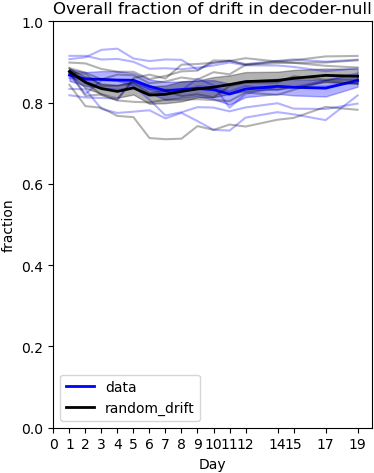

day,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,
170,0.8181,0.8126,0.8116,0.8097,0.8538,0.8326,0.8227,0.8249,0.8400,0.8379,0.8277,0.8412,0.8313,0.8378,0.8543,0.8721
51004,0.8724,0.8210,0.8544,0.8537,0.8413,0.8073,0.7683,0.7763,0.7888,0.7878,0.7786,0.7881,0.7985,0.7852,0.7842,0.7976
51007,0.8608,0.8562,0.8570,0.8548,0.8485,0.8341,0.8321,0.8305,0.8588,0.8427,0.7874,0.8215,0.8399,0.8381,0.8401,0.8499
63,0.8337,0.8327,0.7844,0.7746,0.7776,0.7812,0.7612,0.7746,0.7545,0.7331,0.7311,0.7631,0.7766,0.7712,0.7569,0.8177
64,0.9069,0.9116,0.9298,0.9327,0.9085,0.9023,0.9062,0.9053,0.8807,0.8981,0.9030,0.8948,0.9027,0.9063,0.9007,0.9058
65,0.9150,0.9151,0.9060,0.9075,0.9004,0.8833,0.8847,0.8820,0.8861,0.8913,0.8988,0.8918,0.8913,0.8879,0.8773,0.8844


day,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,
170,0.8846,0.8508,0.8185,0.8065,0.8604,0.8688,0.8591,0.8933,0.8950,0.8981,0.9024,0.9093,0.9009,0.8981,0.8988,0.9041
51004,0.8752,0.8704,0.8414,0.8414,0.8477,0.8234,0.8287,0.8163,0.8206,0.8130,0.8406,0.8489,0.8495,0.8647,0.8565,0.8562
51007,0.8734,0.8166,0.8201,0.8053,0.8019,0.8005,0.8070,0.8072,0.8084,0.8061,0.8039,0.8248,0.8190,0.8315,0.8529,0.8460
63,0.8438,0.7914,0.7873,0.7673,0.7642,0.7128,0.7099,0.7113,0.7422,0.7328,0.7460,0.7411,0.7579,0.7623,0.7894,0.7823
64,0.8849,0.8737,0.8571,0.8690,0.8672,0.8478,0.8519,0.8617,0.8567,0.8748,0.8697,0.8928,0.9015,0.9041,0.9137,0.9149
65,0.8986,0.8965,0.8828,0.8759,0.8758,0.8580,0.8656,0.8768,0.8787,0.9038,0.9032,0.8933,0.8975,0.8979,0.8905,0.8863


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,time,0.027960,15,75,0.001864,3.309634,2.977450e-04,0.084121,0.059214,0.124463
1,condition,0.000083,1,5,0.000083,0.010419,9.226641e-01,0.922664,0.000187,1.000000
2,time * condition,0.015096,15,75,0.001006,5.761173,1.108827e-07,0.010412,0.032866,0.181716


,Timepoint,Condition 1,Condition 2,Test Used,Statistic,p-value,Adjusted p-value (bonferroni),Significance,Effect Size,Effect Size Type,Mean Cond 1,Mean Cond 2,Mean Diff,SD Diff,N,Normal Dist.,Normality p-value
0,d1,data,random_drift,t-test,-0.6963,0.5173,1.0000,,-0.2843,Cohen's d,0.8678,0.8768,-0.0090,0.0315,6,True,0.2228
1,d2,data,random_drift,wilcoxon,9.0000,0.8438,1.0000,,0.1284,r,0.8582,0.8499,0.0083,0.0413,6,False,0.0424
2,d3,data,random_drift,t-test,1.8868,0.1178,1.0000,,0.7703,Cohen's d,0.8572,0.8345,0.0227,0.0294,6,True,0.5411
3,d4,data,random_drift,t-test,2.7732,0.0392,0.6275,,1.1321,Cohen's d,0.8555,0.8276,0.0279,0.0247,6,True,0.3971
4,d5,data,random_drift,t-test,2.0146,0.1001,1.0000,,0.8224,Cohen's d,0.8550,0.8362,0.0188,0.0229,6,True,0.3792
5,d6,data,random_drift,t-test,1.3056,0.2485,1.0000,,0.5330,Cohen's d,0.8401,0.8185,0.0216,0.0405,6,True,0.6660
6,d7,data,random_drift,t-test,0.4590,0.6655,1.0000,,0.1874,Cohen's d,0.8292,0.8204,0.0088,0.0471,6,True,0.2843
7,d8,data,random_drift,t-test,0.2193,0.8351,1.0000,,0.0895,Cohen's d,0.8323,0.8278,0.0045,0.0503,6,True,0.7686
8,d9,data,random_drift,t-test,0.0769,0.9417,1.0000,,0.0314,Cohen's d,0.8348,0.8336,0.0012,0.0384,6,True,0.7983
9,d10,data,random_drift,t-test,-0.4412,0.6775,1.0000,,-0.1801,Cohen's d,0.8318,0.8381,-0.0063,0.0348,6,True,0.9416


day,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,
170,0.8181,0.8126,0.8116,0.8097,0.8538,0.8326,0.8227,0.8249,0.8400,0.8379,0.8277,0.8412,0.8313,0.8378,0.8543,0.8721
51004,0.8724,0.8210,0.8544,0.8537,0.8413,0.8073,0.7683,0.7763,0.7888,0.7878,0.7786,0.7881,0.7985,0.7852,0.7842,0.7976
51007,0.8608,0.8562,0.8570,0.8548,0.8485,0.8341,0.8321,0.8305,0.8588,0.8427,0.7874,0.8215,0.8399,0.8381,0.8401,0.8499
63,0.8337,0.8327,0.7844,0.7746,0.7776,0.7812,0.7612,0.7746,0.7545,0.7331,0.7311,0.7631,0.7766,0.7712,0.7569,0.8177
64,0.9069,0.9116,0.9298,0.9327,0.9085,0.9023,0.9062,0.9053,0.8807,0.8981,0.9030,0.8948,0.9027,0.9063,0.9007,0.9058
65,0.9150,0.9151,0.9060,0.9075,0.9004,0.8833,0.8847,0.8820,0.8861,0.8913,0.8988,0.8918,0.8913,0.8879,0.8773,0.8844


,Source,SS,DF,MS,F,p-unc,ng2,eps
0,time,0.015909,15,0.001061,2.962192,0.000982,0.06589,0.186377
1,Error,0.026853,75,0.000358,NaN,NaN,NaN,NaN


day,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,
170,0.8846,0.8508,0.8185,0.8065,0.8604,0.8688,0.8591,0.8933,0.8950,0.8981,0.9024,0.9093,0.9009,0.8981,0.8988,0.9041
51004,0.8752,0.8704,0.8414,0.8414,0.8477,0.8234,0.8287,0.8163,0.8206,0.8130,0.8406,0.8489,0.8495,0.8647,0.8565,0.8562
51007,0.8734,0.8166,0.8201,0.8053,0.8019,0.8005,0.8070,0.8072,0.8084,0.8061,0.8039,0.8248,0.8190,0.8315,0.8529,0.8460
63,0.8438,0.7914,0.7873,0.7673,0.7642,0.7128,0.7099,0.7113,0.7422,0.7328,0.7460,0.7411,0.7579,0.7623,0.7894,0.7823
64,0.8849,0.8737,0.8571,0.8690,0.8672,0.8478,0.8519,0.8617,0.8567,0.8748,0.8697,0.8928,0.9015,0.9041,0.9137,0.9149
65,0.8986,0.8965,0.8828,0.8759,0.8758,0.8580,0.8656,0.8768,0.8787,0.9038,0.9032,0.8933,0.8975,0.8979,0.8905,0.8863


,Source,SS,DF,MS,F,p-unc,ng2,eps
0,time,0.027147,15,0.00181,4.764527,0.000002,0.110426,0.120681
1,Error,0.028489,75,0.00038,NaN,NaN,NaN,NaN


C:\Users\oles\AppData\Local\Temp\ipykernel_24956\3486472358.py:75: UserWarning: The figure layout has changed to tight
  fig.tight_layout()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


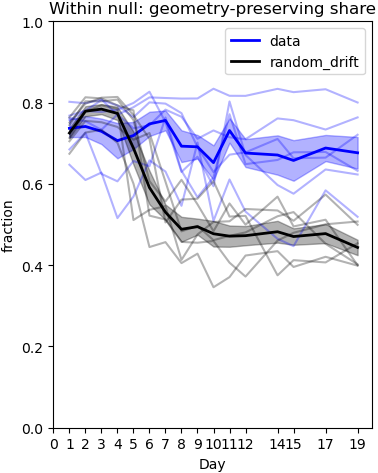

day,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,
170,0.7619,0.7542,0.7331,0.7708,0.7367,0.7441,0.7827,0.7651,0.7111,0.7315,0.7147,0.7099,0.7611,0.7567,0.7337,0.7636
51004,0.7570,0.7793,0.7771,0.7824,0.7991,0.8268,0.7519,0.6294,0.6669,0.5942,0.8028,0.6711,0.5972,0.5759,0.6355,0.6231
51007,0.6848,0.7256,0.6247,0.6063,0.6564,0.6435,0.7633,0.6324,0.5671,0.6160,0.7714,0.6486,0.6589,0.6777,0.6786,0.6322
63,0.6471,0.6095,0.6279,0.5158,0.5689,0.6579,0.6304,0.5461,0.7017,0.5091,0.6108,0.5318,0.4649,0.4468,0.5841,0.5190
64,0.8020,0.7985,0.8076,0.7701,0.7887,0.8128,0.8113,0.8099,0.8102,0.8342,0.8168,0.8166,0.8339,0.8257,0.8329,0.8003
65,0.7680,0.7805,0.8060,0.7929,0.7641,0.8006,0.7975,0.7740,0.6904,0.6289,0.6719,0.6776,0.7106,0.6630,0.6646,0.7209


day,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,
170,0.7049,0.7550,0.7517,0.7401,0.7086,0.7251,0.6054,0.4833,0.4966,0.4615,0.4722,0.4806,0.5203,0.5306,0.4526,0.4020
51004,0.7446,0.8033,0.8031,0.8075,0.7572,0.6068,0.5568,0.6100,0.5496,0.4836,0.5518,0.4997,0.5687,0.4953,0.5118,0.3999
51007,0.7132,0.7782,0.7934,0.7845,0.5110,0.5362,0.5452,0.4130,0.4755,0.5064,0.5080,0.5383,0.5346,0.5092,0.5737,0.4993
63,0.6742,0.7262,0.7333,0.7011,0.6007,0.4446,0.4567,0.4051,0.4283,0.3457,0.3706,0.4237,0.4345,0.3955,0.4206,0.3988
64,0.7636,0.8132,0.8103,0.7932,0.7809,0.5219,0.5122,0.4573,0.4552,0.4596,0.4062,0.3720,0.4605,0.4797,0.5006,0.5074
65,0.7506,0.7973,0.8122,0.8139,0.7692,0.7107,0.5051,0.5613,0.5636,0.6070,0.5196,0.5214,0.3750,0.4123,0.4067,0.4540


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,time,1.040125,15,75,0.069342,22.566951,7.474034e-22,0.000013,0.488062,0.190567
1,condition,0.846666,1,5,0.846666,26.506772,3.619518e-03,0.003620,0.436950,1.000000
2,time * condition,0.577991,15,75,0.038533,13.664828,8.325025e-16,0.000027,0.346310,0.250107


,Timepoint,Condition 1,Condition 2,Test Used,Statistic,p-value,Adjusted p-value (bonferroni),Significance,Effect Size,Effect Size Type,Mean Cond 1,Mean Cond 2,Mean Diff,SD Diff,N,Normal Dist.,Normality p-value
0,d1,data,random_drift,t-test,0.8299,0.4444,1.0000,,0.3388,Cohen's d,0.7368,0.7252,0.0116,0.0344,6,True,0.5057
1,d2,data,random_drift,t-test,-2.1727,0.0819,1.0000,,-0.8870,Cohen's d,0.7413,0.7789,-0.0376,0.0424,6,True,0.0878
2,d3,data,random_drift,t-test,-1.9838,0.1041,1.0000,,-0.8099,Cohen's d,0.7294,0.7840,-0.0546,0.0674,6,True,0.0635
3,d4,data,random_drift,t-test,-1.7968,0.1323,1.0000,,-0.7335,Cohen's d,0.7064,0.7734,-0.0670,0.0913,6,True,0.0646
4,d5,data,random_drift,t-test,1.2333,0.2723,1.0000,,0.5035,Cohen's d,0.7190,0.6880,0.0310,0.0616,6,True,0.2462
5,d6,data,random_drift,t-test,3.7986,0.0126,0.2024,,1.5508,Cohen's d,0.7476,0.5909,0.1568,0.1011,6,True,0.7691
6,d7,data,random_drift,t-test,9.8215,0.0002,0.0030,**,4.0096,Cohen's d,0.7562,0.5302,0.2259,0.0564,6,True,0.1133
7,d8,data,random_drift,t-test,4.3422,0.0074,0.1186,,1.7727,Cohen's d,0.6928,0.4883,0.2045,0.1154,6,True,0.9115
8,d9,data,random_drift,t-test,4.6536,0.0056,0.0890,,1.8998,Cohen's d,0.6912,0.4948,0.1964,0.1034,6,True,0.4522
9,d10,data,random_drift,t-test,3.3713,0.0199,0.3178,,1.3763,Cohen's d,0.6523,0.4773,0.1750,0.1272,6,True,0.7012


day,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,
170,0.7619,0.7542,0.7331,0.7708,0.7367,0.7441,0.7827,0.7651,0.7111,0.7315,0.7147,0.7099,0.7611,0.7567,0.7337,0.7636
51004,0.7570,0.7793,0.7771,0.7824,0.7991,0.8268,0.7519,0.6294,0.6669,0.5942,0.8028,0.6711,0.5972,0.5759,0.6355,0.6231
51007,0.6848,0.7256,0.6247,0.6063,0.6564,0.6435,0.7633,0.6324,0.5671,0.6160,0.7714,0.6486,0.6589,0.6777,0.6786,0.6322
63,0.6471,0.6095,0.6279,0.5158,0.5689,0.6579,0.6304,0.5461,0.7017,0.5091,0.6108,0.5318,0.4649,0.4468,0.5841,0.5190
64,0.8020,0.7985,0.8076,0.7701,0.7887,0.8128,0.8113,0.8099,0.8102,0.8342,0.8168,0.8166,0.8339,0.8257,0.8329,0.8003
65,0.7680,0.7805,0.8060,0.7929,0.7641,0.8006,0.7975,0.7740,0.6904,0.6289,0.6719,0.6776,0.7106,0.6630,0.6646,0.7209


,Source,SS,DF,MS,F,p-unc,ng2,eps
0,time,0.100191,15,0.006679,2.451243,0.005708,0.120816,0.184855
1,Error,0.204368,75,0.002725,NaN,NaN,NaN,NaN


day,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,
170,0.7049,0.7550,0.7517,0.7401,0.7086,0.7251,0.6054,0.4833,0.4966,0.4615,0.4722,0.4806,0.5203,0.5306,0.4526,0.4020
51004,0.7446,0.8033,0.8031,0.8075,0.7572,0.6068,0.5568,0.6100,0.5496,0.4836,0.5518,0.4997,0.5687,0.4953,0.5118,0.3999
51007,0.7132,0.7782,0.7934,0.7845,0.5110,0.5362,0.5452,0.4130,0.4755,0.5064,0.5080,0.5383,0.5346,0.5092,0.5737,0.4993
63,0.6742,0.7262,0.7333,0.7011,0.6007,0.4446,0.4567,0.4051,0.4283,0.3457,0.3706,0.4237,0.4345,0.3955,0.4206,0.3988
64,0.7636,0.8132,0.8103,0.7932,0.7809,0.5219,0.5122,0.4573,0.4552,0.4596,0.4062,0.3720,0.4605,0.4797,0.5006,0.5074
65,0.7506,0.7973,0.8122,0.8139,0.7692,0.7107,0.5051,0.5613,0.5636,0.6070,0.5196,0.5214,0.3750,0.4123,0.4067,0.4540


,Source,SS,DF,MS,F,p-unc,ng2,eps
0,time,1.517925,15,0.101195,31.946448,1.793760e-26,0.807478,0.217451
1,Error,0.237573,75,0.003168,NaN,NaN,NaN,NaN


C:\Users\oles\AppData\Local\Temp\ipykernel_24956\3486472358.py:98: UserWarning: The figure layout has changed to tight
  fig.tight_layout()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


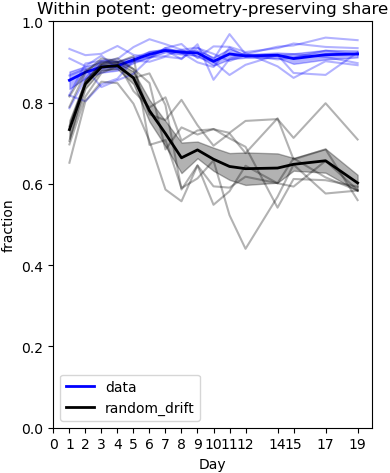

day,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,
170,0.9319,0.9167,0.9201,0.9394,0.9176,0.9120,0.9343,0.9443,0.9097,0.9384,0.9373,0.9244,0.9340,0.9455,0.9370,0.9340
51004,0.7862,0.8597,0.9028,0.9073,0.9366,0.9560,0.9438,0.9299,0.9354,0.9060,0.9686,0.9192,0.9376,0.9406,0.9600,0.9536
51007,0.8668,0.8832,0.8382,0.8551,0.8710,0.9082,0.9344,0.9229,0.8991,0.8876,0.9354,0.9129,0.9152,0.9192,0.9123,0.8972
63,0.9087,0.8896,0.9156,0.8832,0.9014,0.9249,0.9291,0.9069,0.9436,0.8561,0.9072,0.9221,0.8892,0.8609,0.9019,0.8921
64,0.8176,0.8033,0.8449,0.8590,0.9033,0.9005,0.9130,0.9085,0.9342,0.9200,0.9022,0.9170,0.9063,0.9109,0.9279,0.9183
65,0.8190,0.8963,0.9029,0.9008,0.9012,0.9110,0.9146,0.9300,0.9117,0.9006,0.8679,0.8930,0.9173,0.8730,0.8681,0.9235


day,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,
170,0.6972,0.8150,0.8728,0.8897,0.8606,0.8719,0.7939,0.5861,0.6455,0.5939,0.5908,0.6177,0.6016,0.6629,0.6160,0.5836
51004,0.7418,0.8532,0.8958,0.9093,0.8825,0.7710,0.7569,0.8068,0.7444,0.6940,0.7240,0.6756,0.7614,0.6602,0.6852,0.5601
51007,0.7057,0.8521,0.8956,0.8993,0.8285,0.7881,0.8130,0.7066,0.7315,0.7344,0.7255,0.7550,0.7594,0.7132,0.7985,0.7093
63,0.6520,0.8037,0.8514,0.8479,0.7974,0.7061,0.5861,0.5572,0.6453,0.5486,0.5819,0.6446,0.6015,0.5934,0.6566,0.5848
64,0.8151,0.8788,0.9010,0.8988,0.9143,0.6959,0.7078,0.5894,0.6136,0.6577,0.5230,0.4402,0.5684,0.6472,0.5763,0.5835
65,0.7896,0.8735,0.9089,0.9017,0.8827,0.8481,0.6848,0.7390,0.7214,0.7352,0.7120,0.6913,0.5415,0.6121,0.6091,0.5930


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,time,0.362951,15,75,0.024197,12.880412,3.763991e-15,0.000072,0.441091,0.232047
1,condition,1.627693,1,5,1.627693,103.553172,1.572094e-04,0.000157,0.779699,1.000000
2,time * condition,0.556450,15,75,0.037097,17.850043,6.340509e-19,0.000014,0.547500,0.220796


,Timepoint,Condition 1,Condition 2,Test Used,Statistic,p-value,Adjusted p-value (bonferroni),Significance,Effect Size,Effect Size Type,Mean Cond 1,Mean Cond 2,Mean Diff,SD Diff,N,Normal Dist.,Normality p-value
0,d1,data,random_drift,t-test,2.6884,0.0434,0.6941,,1.0975,Cohen's d,0.8550,0.7336,0.1215,0.1107,6,True,0.2420
1,d2,data,random_drift,t-test,1.1139,0.3160,1.0000,,0.4548,Cohen's d,0.8748,0.8460,0.0288,0.0633,6,True,0.6455
2,d3,data,random_drift,t-test,-0.0082,0.9938,1.0000,,-0.0033,Cohen's d,0.8874,0.8876,-0.0002,0.0507,6,True,0.4422
3,d4,data,random_drift,t-test,-0.0206,0.9844,1.0000,,-0.0084,Cohen's d,0.8908,0.8911,-0.0003,0.0381,6,True,0.4795
4,d5,data,random_drift,t-test,2.7850,0.0387,0.6187,,1.1370,Cohen's d,0.9052,0.8610,0.0442,0.0389,6,True,0.9210
5,d6,data,random_drift,t-test,4.4792,0.0065,0.1044,,1.8286,Cohen's d,0.9188,0.7802,0.1386,0.0758,6,True,0.3514
6,d7,data,random_drift,t-test,6.3451,0.0014,0.0230,*,2.5904,Cohen's d,0.9282,0.7238,0.2044,0.0789,6,True,0.4998
7,d8,data,random_drift,t-test,6.5892,0.0012,0.0193,*,2.6900,Cohen's d,0.9238,0.6642,0.2596,0.0965,6,True,0.3736
8,d9,data,random_drift,t-test,9.1122,0.0003,0.0043,**,3.7200,Cohen's d,0.9223,0.6836,0.2387,0.0642,6,True,0.3066
9,d10,data,random_drift,t-test,7.6337,0.0006,0.0098,**,3.1165,Cohen's d,0.9014,0.6606,0.2408,0.0773,6,True,0.6417


day,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,
170,0.9319,0.9167,0.9201,0.9394,0.9176,0.9120,0.9343,0.9443,0.9097,0.9384,0.9373,0.9244,0.9340,0.9455,0.9370,0.9340
51004,0.7862,0.8597,0.9028,0.9073,0.9366,0.9560,0.9438,0.9299,0.9354,0.9060,0.9686,0.9192,0.9376,0.9406,0.9600,0.9536
51007,0.8668,0.8832,0.8382,0.8551,0.8710,0.9082,0.9344,0.9229,0.8991,0.8876,0.9354,0.9129,0.9152,0.9192,0.9123,0.8972
63,0.9087,0.8896,0.9156,0.8832,0.9014,0.9249,0.9291,0.9069,0.9436,0.8561,0.9072,0.9221,0.8892,0.8609,0.9019,0.8921
64,0.8176,0.8033,0.8449,0.8590,0.9033,0.9005,0.9130,0.9085,0.9342,0.9200,0.9022,0.9170,0.9063,0.9109,0.9279,0.9183
65,0.8190,0.8963,0.9029,0.9008,0.9012,0.9110,0.9146,0.9300,0.9117,0.9006,0.8679,0.8930,0.9173,0.8730,0.8681,0.9235


,Source,SS,DF,MS,F,p-unc,ng2,eps
0,time,0.036701,15,0.002447,3.61278,0.000106,0.34557,0.214837
1,Error,0.050793,75,0.000677,NaN,NaN,NaN,NaN


day,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10,d11,d12,d14,d15,d17,d19
animal,,,,,,,,,,,,,,,,
170,0.6972,0.8150,0.8728,0.8897,0.8606,0.8719,0.7939,0.5861,0.6455,0.5939,0.5908,0.6177,0.6016,0.6629,0.6160,0.5836
51004,0.7418,0.8532,0.8958,0.9093,0.8825,0.7710,0.7569,0.8068,0.7444,0.6940,0.7240,0.6756,0.7614,0.6602,0.6852,0.5601
51007,0.7057,0.8521,0.8956,0.8993,0.8285,0.7881,0.8130,0.7066,0.7315,0.7344,0.7255,0.7550,0.7594,0.7132,0.7985,0.7093
63,0.6520,0.8037,0.8514,0.8479,0.7974,0.7061,0.5861,0.5572,0.6453,0.5486,0.5819,0.6446,0.6015,0.5934,0.6566,0.5848
64,0.8151,0.8788,0.9010,0.8988,0.9143,0.6959,0.7078,0.5894,0.6136,0.6577,0.5230,0.4402,0.5684,0.6472,0.5763,0.5835
65,0.7896,0.8735,0.9089,0.9017,0.8827,0.8481,0.6848,0.7390,0.7214,0.7352,0.7120,0.6913,0.5415,0.6121,0.6091,0.5930


,Source,SS,DF,MS,F,p-unc,ng2,eps
0,time,0.882700,15,0.058847,17.943411,5.480478e-19,0.69335,0.223619
1,Error,0.245968,75,0.003280,NaN,NaN,NaN,NaN


In [ ]:
import matplotlib.pyplot as plt

def anova(g, simu_g, row_labels, col_labels, what):
    print_large('\nTWO-WAY REPEATED ANOVA')
    anova=st.repeated_measures_anova_general(
        [np.vstack(g), np.vstack(simu_g)],
        row_labels=row_labels, col_labels=col_labels,
        condition_labels=['data', 'random_drift'],
        title=f'{what}: data vs random drift')
    display(anova[0])
    display(anova[1])
    print_large('\nData:')
    display(st.repeated_measures_anova_single_condition(
        np.vstack(g), row_labels=row_labels, col_labels=col_labels,
        condition_label='data', title=f'{what}: data'))
    print_large('\nRandom Drift:')
    display(st.repeated_measures_anova_single_condition(
        np.vstack(simu_g), row_labels=row_labels, col_labels=col_labels,
        condition_label='random_drift', title=f'{what}: random drift'))


def _collect_series(results_cfg, section, field):
    series = []
    names = []
    for animal, payload in results_cfg.items():
        block = payload.get(section, None)
        if not block: 
            continue
        vals = block.get(field, None)
        if vals is None:
            continue
        series.append(list(vals))
        names.append(animal)
    return series, names

def plot_overall_null_fraction(results_real_cfg, results_simu_cfg, day_labels, colors=('b','k')):
    g_data, names = _collect_series(results_real_cfg, 'nullpot', 'frac_null')
    g_simu, _     = _collect_series(results_simu_cfg, 'nullpot', 'frac_null')

    if len(g_data)==0 and len(g_simu)==0:
        print("[warn] No overall null-fraction data to plot."); 
        return

    fig, ax = plt.subplots(figsize=(4,5))
    plots.plot_average_geometry(
        [g_data, g_simu], day_labels,
        colors=list(colors), labels=['data','random_drift'],
        plot_individual=True, ylim=[0.0, 1.0], ax=ax
    )
    ax.set_title('Overall fraction of drift in decoder-null')
    ax.set_ylabel('fraction'); ax.set_xlabel('Day')
    fig.tight_layout()

    
    plt.show()
    anova(g_data, g_simu, names, st.day_labels(day_labels),
          'Fraction of drift in the decoder null space')

def plot_null_rigid_within_null(results_real_cfg, results_simu_cfg, day_labels, colors=('b','k')):
    g_data, names = _collect_series(results_real_cfg, 'null_within', 'null_rigid_within_null')
    g_simu, _     = _collect_series(results_simu_cfg, 'null_within', 'null_rigid_within_null')

    if len(g_data)==0 and len(g_simu)==0:
        print("[warn] No within-null rigid-share data to plot."); 
        return

    fig, ax = plt.subplots(figsize=(4,5))
    plots.plot_average_geometry(
        [g_data, g_simu], day_labels,
        colors=list(colors), labels=['data','random_drift'],
        plot_individual=True, ylim=[0.0, 1.0], ax=ax
    )
    ax.set_title('Within null: geometry-preserving share')
    ax.set_ylabel('fraction'); ax.set_xlabel('Day')
    fig.tight_layout()
    
    plt.show()
    anova(g_data, g_simu, names, st.day_labels(day_labels),
          'Within null space: geometry-preserving share')

def plot_potent_rigid_within_potent(results_real_cfg, results_simu_cfg, day_labels, colors=('b','k')):
    g_data, names = _collect_series(results_real_cfg, 'null_within', 'potent_rigid_within_potent')
    g_simu, _     = _collect_series(results_simu_cfg, 'null_within', 'potent_rigid_within_potent')
    
    if len(g_data)==0 and len(g_simu)==0:
        print("[warn] No within-potent rigid-share data to plot.")
        return
    
    fig, ax = plt.subplots(figsize=(4,5))
    plots.plot_average_geometry(
        [g_data, g_simu], day_labels,
        colors=list(colors), labels=['data','random_drift'],
        plot_individual=True, ylim=[0.0, 1.0], ax=ax
    )
    ax.set_title('Within potent: geometry-preserving share')
    ax.set_ylabel('fraction'); ax.set_xlabel('Day')
    fig.tight_layout()
    
    plt.show()
    anova(g_data, g_simu, names, st.day_labels(day_labels),
          'Within potent space: geometry-preserving share')

real_cfg = results['config_1']   
simu_cfg = results['config_2']

day_labels = maps


plot_overall_null_fraction(real_cfg, simu_cfg, day_labels)
plot_null_rigid_within_null(real_cfg, simu_cfg, day_labels)
plot_potent_rigid_within_potent(real_cfg, simu_cfg, day_labels)  


